In [38]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

In [39]:
DATA_PATH = Path(
       "analysis_outputs/service_notices_classified_v1_1.csv"
   )

notices = pd.read_csv(
       DATA_PATH,
       dtype={
           "key": "string",
           "lg_code": "string",
           "city_code": "string",
           "project_name": "string",
           "organization_name": "string",
           "matched_subgroups": "string",
       },
   )

notices["cft_issue_date"] = pd.to_datetime(
       notices["cft_issue_date"],
       utc=True,
   ).dt.tz_convert("Asia/Tokyo")

In [41]:
print(f"Rows: {len(notices):,}")
print(f"Columns: {notices.shape[1]:,}")
print(f"IT notices: {notices['it_related'].sum():,}")
print(f"Taxonomy versions:{notices['taxonomy_version'].unique()}")

Rows: 15,230
Columns: 41
IT notices: 762
Taxonomy versions:<StringArray>
['1.1.0']
Length: 1, dtype: str


In [42]:
notices.columns.tolist()

['key',
 'project_name',
 'organization_name',
 'lg_code',
 'prefecture_name',
 'city_code',
 'city_name',
 'cft_issue_date',
 'cft_issue_year',
 'category',
 'procedure_type',
 'external_document_uri',
 'taxonomy_version',
 'it_related',
 'core_it_delivery',
 'digital_or_ai_adjacent',
 'matched_subgroups',
 'subgroup_count',
 'system_development',
 'system_services',
 'software_applications',
 'operations_maintenance',
 'cloud',
 'cybersecurity',
 'network_infrastructure',
 'end_user_computing',
 'data_digital',
 'artificial_intelligence',
 'it_consulting_planning',
 'result_id',
 'date',
 'file_type',
 'file_size',
 'certification',
 'period_end_time',
 'location',
 'tender_submission_deadline',
 'opening_tenders_event',
 'item_code',
 'attachment_count',
 'attachments_json']

In [43]:
column_summary = pd.DataFrame({
       "dtype": notices.dtypes.astype(str),
       "non_null": notices.notna().sum(),
       "missing": notices.isna().sum(),
       "unique": notices.nunique(dropna=True),
   })

column_summary

,dtype,non_null,missing,unique
key,string,15230,0,15230
project_name,string,15230,0,12690
organization_name,string,15230,0,308
lg_code,string,15230,0,6
prefecture_name,str,15230,0,6
city_code,string,11569,3661,98
city_name,str,11569,3661,98
cft_issue_date,"datetime64[us, Asia/Tokyo]",15230,0,1035
cft_issue_year,int64,15230,0,4
category,str,15230,0,1


In [44]:
important_columns = [
       "key",
       "project_name",
       "organization_name",
       "prefecture_name",
       "city_name",
       "cft_issue_date",
       "cft_issue_year",
       "it_related",
       "core_it_delivery",
       "digital_or_ai_adjacent",
       "matched_subgroups",
   ]

notices[important_columns].head(10)

,key,project_name,organization_name,prefecture_name,city_name,cft_issue_date,cft_issue_year,it_related,core_it_delivery,digital_or_ai_adjacent,matched_subgroups
0,YWljaGkvbmNnZy8yMDIyLzIwMjIwMTA0XzAwODMxCg==,実験動物飼育管理業務委託契約,国立研究開発法人国立長寿医療研究センター,愛知県,大府市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
1,Z292MTMvY2JyX21saXRfY2h1YnVfa293YW4vMjAyMi8yMDIyMDEwNF8wMDA2NQo=,令和３年度 中部地方整備局港湾WANシステム機器賃貸借,国土交通省中部地方整備局港湾空港部,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
2,Z292Ny9jYnJfbWxpdC8yMDIyLzIwMjIwMTA0XzAzODI0Cg==,令和４年度 越美山系電気通信施設保守業務,国土交通省中部地方整備局,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
3,Z292Ny9jYnJfbWxpdC8yMDIyLzIwMjIwMTA0XzAzODIxCg==,令和４年度 中部管内河川・道路管理気象予測提供業務,国土交通省中部地方整備局,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
4,Z292Ny9jYnJfbWxpdC8yMDIyLzIwMjIwMTA0XzAzODIyCg==,令和４年度 丸山ダム電気通信施設保守業務,国土交通省中部地方整備局,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
5,Z292Ny9jYnJfbWxpdC8yMDIyLzIwMjIwMTA0XzAzODIzCg==,令和４年度 横山ダム電気通信施設保守業務,国土交通省中部地方整備局,愛知県,名古屋市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
6,a2FuYWdhd2Eva2Vuc2F0c3VfeW9rb2hhbWEvMjAyMi8yMDIyMDEwNF8wMDA3Mgo=,「令和４年度保土ヶ谷区検察庁歳入金等警備輸送業務委託契約」に係る入札について,検察庁横浜地方検察庁,神奈川県,横浜市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
7,aG9ra2FpZG8vaG9ra2FpZG9fcm91ZG91a3lva3UvMjAyMi8yMDIyMDEwNF8wMTgzMAo=,令和4年度庁舎機械警備業務委託契約（34施設）,厚生労働省北海道労働局,北海道,札幌市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
8,b3Nha2EvaGlnYXNoaW9zYWthX2NpdHkvMjAyMi8yMDIyMDEwNF8wMDM5Ngo=,(R3ポ-4)自動水質監視装置及びテレメータ更新工事に伴う測量等業務委託 (サイズ：508.72KB),大阪府東大阪市,大阪府,東大阪市,2022-01-04 00:00:00+09:00,2022,False,False,False,<NA>
9,Z292OS9qcG5zcG9ydC8yMDIyLzIwMjIwMTA1XzAwNjYwCg==,国立代々木競技場産業廃棄物・リサイクル処理業務委託,独立行政法人日本スポーツ振興センター,東京都,港区,2022-01-05 00:00:00+09:00,2022,False,False,False,<NA>


In [45]:
assert not (
       notices["core_it_delivery"]
       & notices["digital_or_ai_adjacent"]
).any()

In [46]:
subgroup_columns = [
       "system_development",
       "system_services",
       "software_applications",
       "operations_maintenance",
       "cloud",
       "cybersecurity",
       "network_infrastructure",
       "end_user_computing",
       "data_digital",
       "artificial_intelligence",
       "it_consulting_planning",
   ]

In [47]:
notices[subgroup_columns].sum().sort_values(ascending=False)

operations_maintenance     293
system_development         227
network_infrastructure     145
software_applications       67
data_digital                55
cloud                       50
artificial_intelligence     41
cybersecurity               32
it_consulting_planning      30
system_services             19
end_user_computing           4
dtype: int64

In [48]:
sparse_columns = [
       "procedure_type",
       "period_end_time",
       "location",
       "tender_submission_deadline",
       "opening_tenders_event",
       "item_code",
   ]

notices[sparse_columns].notna().mean().sort_values()

period_end_time              0.00
location                     0.00
item_code                    0.00
tender_submission_deadline   0.01
opening_tenders_event        0.01
procedure_type               0.21
dtype: float64

In [49]:
notices[
       ["it_related", "core_it_delivery",
 "digital_or_ai_adjacent"]
   ].value_counts()

it_related  core_it_delivery  digital_or_ai_adjacent
False       False             False                     14468
True        True              False                       691
            False             True                         71
Name: count, dtype: int64

In [50]:
it_notices = notices.loc[notices["it_related"]].copy()

print(f"IT notices: {len(it_notices):,}")

IT notices: 762


In [57]:
## 1. How did IT-indicator counts and shares change from 2022 to 2025?


annual_summary = (
       notices.groupby("cft_issue_year", as_index=False)
       .agg(
           service_notices=("key", "size"),
           it_notices=("it_related", "sum"),
           core_it_notices=("core_it_delivery", "sum"),
           adjacent_only_notices=("digital_or_ai_adjacent",
 "sum"),
       )
   )

annual_summary["it_share_percent"] = (
       annual_summary["it_notices"]
       / annual_summary["service_notices"]
       * 100
   )

annual_summary["core_it_share_percent"] = (
       annual_summary["core_it_notices"]
       / annual_summary["service_notices"]
       * 100
   )

annual_summary["adjacent_only_share_percent"] = (
       annual_summary["adjacent_only_notices"]
       / annual_summary["service_notices"]
       * 100
   )


annual_summary["it_notice_absolute_change"] = (
       annual_summary["it_notices"].diff()
   )

annual_summary["it_notice_yoy_percent"] = (
       annual_summary["it_notices"].pct_change() * 100
   )

annual_summary["it_share_pp_change"] = (
       annual_summary["it_share_percent"].diff()
   )

annual_summary.round({
       "it_share_percent": 2,
       "core_it_share_percent": 2,
       "adjacent_only_share_percent": 2,
       "it_notice_yoy_percent": 1,
       "it_share_pp_change": 2,
   })



annual_summary.round({
       "it_share_percent": 2,
       "core_it_share_percent": 2,
       "adjacent_only_share_percent": 2,
       "it_notice_yoy_percent": 1,
       "it_share_pp_change": 2,
   })

annual_summary



# Absolute change: Allows us to measure the difference of it notices issued 
# YoY percentage change: How large was the change compared with where it started? 
# Percentage-point change: Did IT become a larger or smaller part of all service notices?


,cft_issue_year,service_notices,it_notices,core_it_notices,adjacent_only_notices,it_share_percent,core_it_share_percent,adjacent_only_share_percent,it_notice_absolute_change,it_notice_yoy_percent,it_share_pp_change
0,2022,2497,117,108,9,4.69,4.33,0.36,NaN,NaN,NaN
1,2023,3836,183,162,21,4.77,4.22,0.55,66.00,56.41,0.08
2,2024,4458,201,180,21,4.51,4.04,0.47,18.00,9.84,-0.26
3,2025,4439,261,241,20,5.88,5.43,0.45,60.00,29.85,1.37


In [59]:
annual_summary = annual_summary.sort_values(
       "cft_issue_year"
   ).reset_index(drop=True)

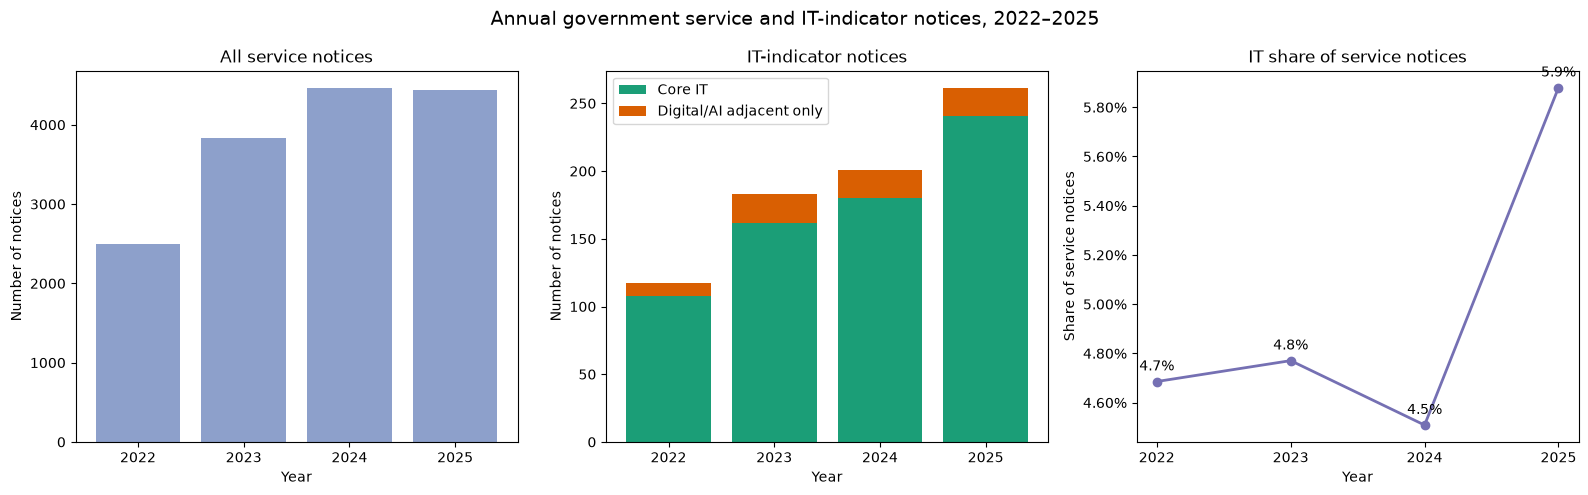

In [61]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

years = annual_summary["cft_issue_year"]

fig, axes = plt.subplots(
       1,
       3,
       figsize=(16, 5),
   )

   # Panel 1: all service notices
axes[0].bar(
       years,
       annual_summary["service_notices"],
       color="#8da0cb",
   )

axes[0].set_title("All service notices")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of notices")
axes[0].set_xticks(years)

   # Panel 2: IT notices split into core and adjacent-only
axes[1].bar(
       years,
       annual_summary["core_it_notices"],
       label="Core IT",
       color="#1b9e77",
   )

axes[1].bar(
       years,
       annual_summary["adjacent_only_notices"],
       bottom=annual_summary["core_it_notices"],
       label="Digital/AI adjacent only",
       color="#d95f02",
   )

axes[1].set_title("IT-indicator notices")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of notices")
axes[1].set_xticks(years)
axes[1].legend()

   # Panel 3: IT share of all service notices
axes[2].plot(
       years,
       annual_summary["it_share_percent"],
       marker="o",
       linewidth=2,
       color="#7570b3",
   )

axes[2].set_title("IT share of service notices")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Share of service notices")
axes[2].set_xticks(years)
axes[2].yaxis.set_major_formatter(PercentFormatter())

for year, share in zip(
       years,
       annual_summary["it_share_percent"],
       strict=True,
   ):
       axes[2].annotate(
           f"{share:.1f}%",
           (year, share),
           xytext=(0, 8),
           textcoords="offset points",
           ha="center",
       )

fig.suptitle(
       "Annual government service and IT-indicator notices, 2022–2025",
       fontsize=14,
   )

fig.tight_layout()
plt.show()

In [64]:
from pathlib import Path

Path("analysis_outputs/report_figures").mkdir(
       parents=True,
       exist_ok=True,
   )


In [66]:
fig.savefig(
       "analysis_outputs/report_figures/annual_it_trend.png",
       dpi=300,
       bbox_inches="tight",
   )

In [67]:
# 2. Which IT subgroups experienced the largest absolute and relative increases, and which gained or lost representation among IT notices

subgroup_labels = {
       "system_development": "System development",
       "system_services": "System services",
       "software_applications": "Software and applications",
       "operations_maintenance": "Operations and maintenance",
       "cloud": "Cloud",
       "cybersecurity": "Cybersecurity",
       "network_infrastructure": "Network infrastructure",
       "end_user_computing": "End-user computing",
       "data_digital": "Data and digital",
       "artificial_intelligence": "Artificial intelligence",
       "it_consulting_planning": "IT consulting and planning",
   }


In [72]:
subgroup_annual = (
       notices.groupby(
           "cft_issue_year",
           as_index=False,
       )[subgroup_columns]
       .sum()
       .melt(
           id_vars="cft_issue_year",
           var_name="subgroup",
           value_name="notice_count",
       )
   )


annual_it_totals = (
       notices.groupby(
           "cft_issue_year",
           as_index=False,
       )
       .agg(
           it_notices=("it_related", "sum"),
       )
   )

subgroup_annual = subgroup_annual.merge(
       annual_it_totals,
       on="cft_issue_year",
       validate="many_to_one",
   )

subgroup_annual["subgroup_label"] = (
       subgroup_annual["subgroup"].map(subgroup_labels)
   )


subgroup_annual = subgroup_annual.sort_values(
       ["subgroup", "cft_issue_year"]
   ).reset_index(drop=True)

subgroup_annual["previous_year_count"] = (
       subgroup_annual.groupby("subgroup")[
           "notice_count"
       ].shift(1)
   )



In [74]:
subgroup_annual["absolute_annual_change"] = (
       subgroup_annual["notice_count"]
       - subgroup_annual["previous_year_count"]
   )

In [76]:
subgroup_annual["yoy_percent"] = (
       (
           subgroup_annual["notice_count"]
           / subgroup_annual["previous_year_count"]
           - 1
       )
       * 100
   )

In [78]:
 subgroup_annual.loc[
       subgroup_annual["previous_year_count"].eq(0),
       "yoy_percent",
   ] = pd.NA

In [80]:
subgroup_annual["share_of_it_percent"] = (
       subgroup_annual["notice_count"]
       / subgroup_annual["it_notices"]
       * 100
   )

In [82]:
subgroup_annual["share_pp_change"] = (
       subgroup_annual.groupby("subgroup")[
           "share_of_it_percent"
       ].diff()
   )

In [84]:
subgroup_annual[
       [
           "cft_issue_year",
           "subgroup_label",
           "notice_count",
           "absolute_annual_change",
           "yoy_percent",
           "share_of_it_percent",
           "share_pp_change",
       ]
   ].round(2)

,cft_issue_year,subgroup_label,notice_count,absolute_annual_change,yoy_percent,share_of_it_percent,share_pp_change
0,2022,Artificial intelligence,4,NaN,NaN,3.42,NaN
1,2023,Artificial intelligence,6,2.00,50.00,3.28,-0.14
2,2024,Artificial intelligence,13,7.00,116.67,6.47,3.19
3,2025,Artificial intelligence,18,5.00,38.46,6.90,0.43
4,2022,Cloud,6,NaN,NaN,5.13,NaN
5,2023,Cloud,9,3.00,50.00,4.92,-0.21
6,2024,Cloud,14,5.00,55.56,6.97,2.05
7,2025,Cloud,21,7.00,50.00,8.05,1.08
8,2022,Cybersecurity,4,NaN,NaN,3.42,NaN
9,2023,Cybersecurity,6,2.00,50.00,3.28,-0.14


In [85]:
subgroup_wide = subgroup_annual.pivot(
       index="subgroup",
       columns="cft_issue_year",
       values=[
           "notice_count",
           "share_of_it_percent",
       ],
   )

subgroup_change_summary = pd.DataFrame({
       "count_2022": subgroup_wide["notice_count"][2022],
       "count_2025": subgroup_wide["notice_count"][2025],
       "share_2022_percent": (
           subgroup_wide["share_of_it_percent"][2022]
       ),
       "share_2025_percent": (
           subgroup_wide["share_of_it_percent"][2025]
       ),
   })


subgroup_change_summary[
       "absolute_change_2022_2025"
   ] = (
       subgroup_change_summary["count_2025"]
       - subgroup_change_summary["count_2022"]
   )





In [87]:
def calculate_cagr(
       start: float,
       end: float,
       periods: int = 3,
   ) -> float | None:
       if start <= 0:
           return None

       return ((end / start) ** (1 / periods) - 1) * 100


subgroup_change_summary[
       "cagr_2022_2025_percent"
   ] = subgroup_change_summary.apply(
       lambda row: calculate_cagr(
           row["count_2022"],
           row["count_2025"],
       ),
       axis=1,
   )

In [89]:
subgroup_change_summary[
       "share_pp_change_2022_2025"
   ] = (
       subgroup_change_summary["share_2025_percent"]
       - subgroup_change_summary["share_2022_percent"]
   )

subgroup_change_summary["subgroup_label"] = (
       subgroup_change_summary.index.map(subgroup_labels)
   )

subgroup_change_summary = (
       subgroup_change_summary
       .sort_values(
           "absolute_change_2022_2025",
           ascending=False,
       )
   )

subgroup_change_summary[
       [
           "subgroup_label",
           "count_2022",
           "count_2025",
           "absolute_change_2022_2025",
           "cagr_2022_2025_percent",
           "share_2022_percent",
           "share_2025_percent",
           "share_pp_change_2022_2025",
       ]
   ].round(2)

,subgroup_label,count_2022,count_2025,absolute_change_2022_2025,cagr_2022_2025_percent,share_2022_percent,share_2025_percent,share_pp_change_2022_2025
subgroup,,,,,,,,
system_development,System development,35.00,95.00,60.00,39.49,29.91,36.40,6.48
operations_maintenance,Operations and maintenance,43.00,87.00,44.00,26.48,36.75,33.33,-3.42
network_infrastructure,Network infrastructure,22.00,47.00,25.00,28.79,18.80,18.01,-0.80
cloud,Cloud,6.00,21.00,15.00,51.83,5.13,8.05,2.92
artificial_intelligence,Artificial intelligence,4.00,18.00,14.00,65.10,3.42,6.90,3.48
software_applications,Software and applications,9.00,22.00,13.00,34.71,7.69,8.43,0.74
cybersecurity,Cybersecurity,4.00,15.00,11.00,55.36,3.42,5.75,2.33
it_consulting_planning,IT consulting and planning,7.00,13.00,6.00,22.92,5.98,4.98,-1.00
end_user_computing,End-user computing,0.00,1.00,1.00,NaN,0.00,0.38,0.38


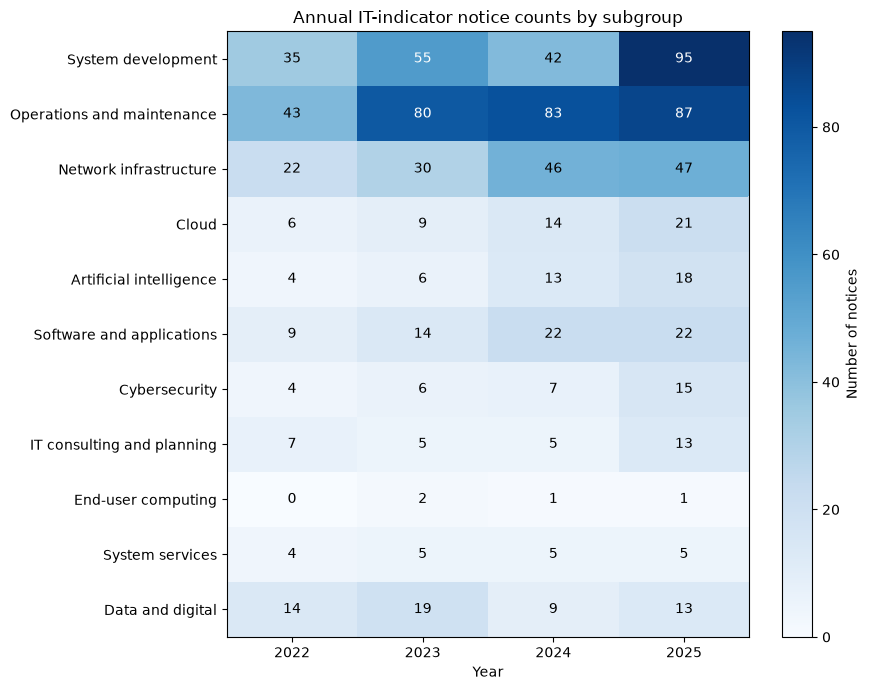

In [91]:
subgroup_matrix = (
       subgroup_annual.pivot(
           index="subgroup_label",
           columns="cft_issue_year",
           values="notice_count",
       )
       .loc[
           subgroup_change_summary["subgroup_label"]
       ]
   )

fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
       subgroup_matrix,
       cmap="Blues",
       aspect="auto",
   )

ax.set_xticks(range(len(subgroup_matrix.columns)))
ax.set_xticklabels(subgroup_matrix.columns)

ax.set_yticks(range(len(subgroup_matrix.index)))
ax.set_yticklabels(subgroup_matrix.index)

ax.set_xlabel("Year")
ax.set_title("Annual IT-indicator notice counts by subgroup")

for row_index in range(len(subgroup_matrix.index)):
    for column_index in range(len(subgroup_matrix.columns)):
           value = subgroup_matrix.iloc[
               row_index,
               column_index,
           ]

           ax.text(
               column_index,
               row_index,
               f"{int(value)}",
               ha="center",
               va="center",
               color=(
                   "white"
                   if value > subgroup_matrix.to_numpy().max() * 0.55
                   else "black"
               ),
           )

fig.colorbar(
       image,
       ax=ax,
       label="Number of notices",
   )

fig.tight_layout()
plt.show()

In [32]:
# 3. Which of the six selected prefectures experienced the largest changes in IT-indicator notice counts and IT shares from 2022 to 2025? 




In [33]:
# Which organizations have been issuing the most it related services in each rpefecture year over year


In [34]:
# which organizations have seen the biggest increases year over year and particuarly, in which subgroup

In [35]:
# Do we see any type of increases in competitive biddings, open, and public biddings 

In [36]:
# How do services differ in the type of bidding that is produced? Do we see large more public biddings for certain services?

In [ ]:
# Which subgroups have a larger number of public biddings, and private bidings, what is the split